In [1]:
%load_ext autoreload
%autoreload 2

# Trade Strategy 20250603

## Description
Combine various individual strategies and assets to create a portfolio.

## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import TickerPriceDataFetcher
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns, calculate_MA_returns, calculate_relative_volume
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models
from scipy import stats

from utils.helpers import constrained_linear_regression, gmean, hmean, compute_r2, normalize_weights



Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


c:\Users\alexr\AlgoTester\utils\data_fetcher.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Utils

## Parameters

In [4]:
LOOKFORWARD_PERIOD = 21
LOOKBACK_PERIODS=[21, 50, 100, 200, 252]
REBALANCE_PERIOD = 21

COVAR_LOOKBACK_PERIOD = 252
HISTORY_LOOKBACK_PERIOD = 252 * 2

CURRENT_DATE = datetime.datetime.now().date()
CURRENT_DATE = CURRENT_DATE.strftime("%Y%m%d")

tickers_to_fetch = [
    'IB01.L', 
    'SHV', 
    'SPY', 
    'TLT', 
    'GLD', 
    '^VIX', 
    '^GVZ', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM', 
    'LQD', 
    'IBIT', 
    'USO', 
    'CPER', 
    'OPEN',
    'UURAF',
    'UUUU',
    'ABAT',
    'LAC',
    'TMC',
    'MP',
    'UPRO',
    'TMF'
]

risky_asset_tickers = {
    # 'IB01.L', 
    # 'SHV', 
    'SPY', 
    'TLT', 
    'GLD', 
    # '^VIX', 
    # '^GVZ', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM', 
    'LQD', 
    'IBIT', 
    'USO', 
    'CPER', 
    'OPEN',
    'UURAF',
    'UUUU',
    'ABAT',
    'LAC',
    'TMC',
    'MP',
    'UPRO',
    'TMF'
}


## Load Data

In [5]:
fetcher = TickerPriceDataFetcher()
price_data = fetcher.load_data(ticker_list=tickers_to_fetch)

for ticker in price_data:
    print(ticker, price_data[ticker].index.to_list()[0], price_data[ticker].index.to_list()[-1])
    # display(price_data[ticker])


2025-08-23 20:50:06,769 - utils.data_fetcher - INFO - Loading data for ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO', 'CPER', 'OPEN', 'UURAF', 'UUUU', 'ABAT', 'LAC', 'TMC', 'MP', 'UPRO', 'TMF']
2025-08-23 20:50:06,770 - utils.data_fetcher - INFO - Fetching data for IB01.L with yfinance
2025-08-23 20:50:07,322 - utils.data_fetcher - INFO - Moved IB01.L_20250731.pkl to archive
2025-08-23 20:50:07,324 - utils.data_fetcher - INFO - Data for SHV already exists
2025-08-23 20:50:07,326 - utils.data_fetcher - INFO - Data for SPY already exists
2025-08-23 20:50:07,327 - utils.data_fetcher - INFO - Data for TLT already exists
2025-08-23 20:50:07,329 - utils.data_fetcher - INFO - Data for GLD already exists
2025-08-23 20:50:07,330 - utils.data_fetcher - INFO - Fetching data for ^VIX with yfinance
2025-08-23 20:50:07,565 - utils.data_fetcher - INFO - Moved ^VIX_20250731.pkl to archive
2025-08-23 20:50:07,568 - utils.data_fetcher - INFO - F

IB01.L 2019-02-20 00:00:00 2025-08-22 00:00:00
SHV 2007-01-11 00:00:00 2025-08-22 00:00:00
SPY 1993-01-29 00:00:00 2025-08-22 00:00:00
TLT 2002-07-30 00:00:00 2025-08-22 00:00:00
GLD 2004-11-18 00:00:00 2025-08-22 00:00:00
^VIX 1990-01-02 00:00:00 2025-08-22 00:00:00
^GVZ 2008-06-03 00:00:00 2025-08-22 00:00:00
PPLT 2010-01-08 00:00:00 2025-08-22 00:00:00
URA 2010-11-05 00:00:00 2025-08-22 00:00:00
DBA 2007-01-05 00:00:00 2025-08-22 00:00:00
EEM 2003-04-14 00:00:00 2025-08-22 00:00:00
LQD 2002-07-30 00:00:00 2025-08-22 00:00:00
IBIT 2024-01-11 00:00:00 2025-08-22 00:00:00
USO 2006-04-10 00:00:00 2025-08-22 00:00:00
CPER 2011-11-15 00:00:00 2025-08-22 00:00:00
OPEN 2020-06-18 00:00:00 2025-08-22 00:00:00
UURAF 2010-01-05 00:00:00 2025-08-22 00:00:00
UUUU 2007-03-19 00:00:00 2025-08-22 00:00:00
ABAT 2016-02-24 00:00:00 2025-08-22 00:00:00
LAC 2023-10-02 00:00:00 2025-08-22 00:00:00
TMC 2021-09-10 00:00:00 2025-08-22 00:00:00
MP 2020-06-22 00:00:00 2025-08-22 00:00:00
UPRO 2009-06-25 00:0

## Process Data
### Function

In [5]:
def process_price_data(
        df, 
        lookforward_period=21, 
        lookback_periods=[21, 100, 200, 252], 
        rebalance_period=21,
        vix_ticker=None
    ):
    # Calculate indicators
    df['ret'] = df['close'].pct_change()
    df['ret_next_day'] = df['ret'].shift(-1)
    df['vol_forward'] = calculate_forward_vol(df, lookforward_period)
    df['ret_forward'] = calculate_forward_returns(df, lookforward_period)
    df['var_forward'] = df['vol_forward'] ** 2
    df['sharpe_forward'] = ((df['ret_forward'] + 1) ** (252 / lookforward_period) - 1) / (df['vol_forward'] * np.sqrt(252 / lookforward_period))
    
    if vix_ticker is not None:
        df['VIX'] = price_data[vix_ticker]['close'].copy()
    for period in lookback_periods:
        df[f'MA_{period}'] = df['close'].rolling(period).mean()
        df[f'EMA_{period}'] = df['close'].ewm(span=period, adjust=False).mean()
        df[f'MA_ret_{period}'] = calculate_MA_returns(df, period)
        df[f'vol_{period}'] = df['ret'].rolling(period).std()

        if period > rebalance_period: 
            df[f'high_breakout_{period}'] = (df['close'].rolling(period).max() - df['close'].rolling(rebalance_period).max()) / df['close'].rolling(rebalance_period).max()
            df[f'low_breakout_{period}'] = (df['close'].rolling(period).min() - df['close'].rolling(rebalance_period).min()) / df['close'].rolling(rebalance_period).min()

        df[f'upper_bollinger_{period}'] = df['close'].rolling(period).mean() + 2 * df['close'].rolling(period).std()
        df[f'lower_bollinger_{period}'] = df['close'].rolling(period).mean() - 2 * df['close'].rolling(period).std()

        df[f'ATR_{period}'] = calculate_atr(df, period)
        df[f'relative_volume_{period}'] = calculate_relative_volume(df, rebalance_period, period)
    
    
    def compute_r2_signal(y):
        return compute_r2(np.log(y))

    for period in lookback_periods:
        df[f'r2_{period}'] = df['close'].rolling(period).apply(compute_r2_signal)

    for period in lookback_periods:
        df[f'tech_ind_ma_ret_{period}'] = (df['close'] - df[f'MA_{period}']) / df[f'MA_{period}']
        df[f'tech_ind_ema_ret_{period}'] = (df['close'] - df[f'EMA_{period}']) / df[f'EMA_{period}']
        df[f'tech_ind_ma_vol_{period}'] = (df['close'] - df[f'MA_{period}']) / df[f'vol_{period}']

        # df[f'tech_ind_lagged_ret_{period}'] =  (df['close'].shift(21) - df['close'].shift(period + 21)) / df['close'].shift(period + 21)
        
        df[f'tech_ind_upper_bollinger_{period}'] = (df['high'] - df[f'upper_bollinger_{period}'])
        df[f'tech_ind_lower_bollinger_{period}'] = (df['low'] - df[f'lower_bollinger_{period}'])
        
        if period > rebalance_period:
            df[f'tech_ind_high_breakout'] = df[f'high_breakout_{period}']
            df[f'tech_ind_low_breakout'] = df[f'low_breakout_{period}']
        
    
    df = df.copy()
    return df



### Generate indicators

In [6]:
ticker_settings = {
    "SPY": {
        "VIX": "^VIX",
    },
    "GLD": {
        "VIX": "^GVZ"
    },
    "UPRO": {
        "VIX": "^VIX"
    }
}

risky_assets = dict()
for ticker in risky_asset_tickers:
    vix_ticker = None
    if ticker in ticker_settings:
        vix_ticker = ticker_settings[ticker]["VIX"]
    
    df = price_data[ticker].copy()
    df = process_price_data(
        df,
        lookforward_period=LOOKFORWARD_PERIOD,
        lookback_periods=LOOKBACK_PERIODS,
        rebalance_period=REBALANCE_PERIOD,
        vix_ticker=vix_ticker,
    )

    risky_assets[ticker] = {}
    risky_assets[ticker]['data'] = df

TICKERS_TO_TEST = [
    "SPY",
    "GLD",
    "TLT",
    "LQD",
    "UPRO",
    "TMF",
]

## Define Strategy

In [18]:



def allocation_func(
    ticker_list, 
    lookback_periods, 
    historical_period, 
    current_date,
    dict_data,
    covariance_matrix_lookback,
    verbose=False
):
    #################################################################
    # Correlation Optimization
    # Use HRP to optimize for correlation between assets
    # skip if we only have one ticker
    #################################################################
    if len(ticker_list) > 1:
        df_combined = pd.DataFrame()
        for ticker in ticker_list:
            if ticker in ['UPRO', 'TMF']: continue
            df_data = dict_data[ticker].copy()
            df_data = df_data[df_data.index <= current_date].copy()
            df_data = df_data.iloc[-historical_period:]
            df_data['returns'] = df_data['close'].pct_change()
            df_combined[ticker] = df_data['returns']
        df_combined.dropna(inplace=True)

        # Covariance Matrix with Exponentially Weighted Moving Average
        ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)
        
        # Convariance Matrix with Ledoit Wolf shrinkage
        ledoit_wolf_cov = risk_models.CovarianceShrinkage(
            prices=df_combined.iloc[-covariance_matrix_lookback:], 
            returns_data=True
        ).ledoit_wolf()

        # Final Covariance Matrix is mean of EWMA and Ledoit Wolf
        cov = (ledoit_wolf_cov + ewma_cov) / 2

        # HRP to generate asset allocation weights
        hrpopt = HRPOpt(
            cov_matrix=cov
        )
        asset_allocation_weights = hrpopt.optimize()

            
    else:
        # Single asset case
        asset_allocation_weights = {ticker_list[0]: 1}
    

    #################################################################
    # Volatility Optimization
    # Higher volatility -> lower weight
    #################################################################
    volatility_weights = {}
    for ticker in ticker_list:
        # Limit data to current date
        df_data = dict_data[ticker]
        df_data = df_data[df_data.index <= current_date].copy()
        
        # Limit date to lookback period
        # df_data = df_data.iloc[-(historical_period + REBALANCE_PERIOD + 2):-(REBALANCE_PERIOD + 2)]
        df_data = df_data.iloc[:-(REBALANCE_PERIOD + 2)]
        
        # Define features
        X_features = []
        for period in lookback_periods:
            X_features.append(f'vol_{period}')
            # X_features.append(f'r2_{period}')
            # X_features.append(f'ATR_{period}')
        if 'VIX' in df_data.columns:
            X_features.append('VIX')
        df_train = df_data[X_features + ['vol_forward']].copy()

        # drop na values
        df_train = df_train.dropna()

        # Scale features
        X_scaler = RobustScaler()
        df_train[X_features] = X_scaler.fit_transform(df_train[X_features])

        # Split into train and test
        X_train = df_train[X_features].iloc[:-1]
        X_test =  df_data[X_features].iloc[-1:]
        X_test = pd.DataFrame(X_test, columns=X_features)
        X_test[X_features] = X_scaler.transform(X_test)
        
        if verbose:
            print('-------------------------------------------------------')
            print(ticker, X_train.index.values[-1], X_test.index.values[0])

        # y feature = vol forward
        y_train = df_train['vol_forward'].iloc[:-1]
        model = LinearRegression()
        model.fit(X_train, y_train)
        vol_forecast = model.predict(X_test)[0]

        # Transform vol forecast to be between 0 and 1 as percentile of vol distribution
        # Higher vol forecast = lower vol scaling factor
        pct_rank = stats.percentileofscore(y_train[-historical_period:], vol_forecast, kind='rank') / 100
        vol_scaling_factor = (1 - pct_rank) * 1.0

        volatility_weights[ticker] = vol_scaling_factor

        
    # #################################################################
    # # Return Optimization
    # #################################################################
    # return_weights = {}
    # for ticker in ticker_list:
    #     # Limit data to current date
    #     df_data = dict_data[ticker]
    #     df_data = df_data[df_data.index <= current_date].copy()
        
    #     # Limit date to lookback period
    #     df_data = df_data.iloc[-(historical_period + REBALANCE_PERIOD + 2):-(REBALANCE_PERIOD + 2)]
        
    #     # Define features
    #     X_features = [f for f in df_data if f.startswith('tech_ind')]
    #     for period in lookback_periods:
    #         X_features.append(f'vol_{period}')
    #         X_features.append(f'r2_{period}')
    #         X_features.append(f'ATR_{period}')
    #     if 'VIX' in df_data.columns:
    #         X_features.append('VIX')
    #     df_train = df_data[X_features + ['ret_forward']].copy()

    #     # drop na values
    #     df_train = df_train.dropna()

    #     # Scale features
    #     X_scaler = RobustScaler()
    #     df_train[X_features] = X_scaler.fit_transform(df_train[X_features])

    #     # Split into train and test
    #     X_train = df_train[X_features].iloc[:-1]
    #     X_test =  df_data[X_features].iloc[-1:]
    #     X_test = pd.DataFrame(X_test, columns=X_features)
    #     X_test[X_features] = X_scaler.transform(X_test)
        
    #     if verbose:
    #         print('-------------------------------------------------------')
    #         print(ticker, X_train.index.values[-1], X_test.index.values[0])

    #     # y feature = vol forward
    #     y_train = df_train['ret_forward'].iloc[:-1]
    #     model = LinearRegression()
    #     model.fit(X_train, y_train)
    #     ret_forecast = model.predict(X_test)[0]

    #     if ret_forecast < 0:
    #         ret_scaling_factor = -0.05
    #     else:
    #         # Transform vol forecast to be between 0 and 1 as percentile of vol distribution
    #         # Higher vol forecast = lower vol scaling factor
    #         pct_rank = stats.percentileofscore(y_train[-historical_period:], ret_forecast, kind='rank') / 100
    #         ret_scaling_factor = pct_rank

    #     return_weights[ticker] = ret_scaling_factor


    #################################################################
    # Combination of all optimizations
    #################################################################
    final_weights = {}
    for ticker in ticker_list:
        if ticker in ['UPRO', 'TMF']: continue
        final_weights[ticker] = (
            asset_allocation_weights[ticker]
            * volatility_weights[ticker]
            # * return_weights[ticker]
        )
    
    # # Limit weights to be between 5% and 50%
    # for ticker in ticker_list:
    #     if ticker in ['UPRO', 'TMF']: continue
    #     final_weights[ticker] = np.clip(final_weights[ticker], 0.05, 0.5)
    
    sum_weights = 0
    for ticker in final_weights:
        weight = np.abs(final_weights[ticker])
        sum_weights += weight
    final_weights = {ticker: final_weights[ticker] / sum_weights for ticker in final_weights}
    return final_weights
    




In [19]:
from strategies.base import BaseStrategy

ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

class MultiAssetStrategy(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('lookback_periods', [21, 100, 200, 252]),
        ('dict_data', dict()),
        ('historical_period', 252*2),
        ('covariance_matrix_lookback', 252),
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0

        self.dict_data = self.p.dict_data
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            self.rebalance()
            
        
        self.rebalance_day += 1


    def rebalance(self):
        current_capital = self.broker.getvalue()
        current_date = pd.to_datetime(self.datetime.date())

        

            
        
        # leverage_tracker.append(sum(asset_allocation_weights.values()))
        asset_allocation_weights = allocation_func(
            ticker_list=self.p.tickers, 
            lookback_periods=self.p.lookback_periods, 
            historical_period=self.p.historical_period, 
            current_date=current_date,
            dict_data=self.p.dict_data,
            covariance_matrix_lookback=self.p.covariance_matrix_lookback,
        )
        leverage_tracker.append(sum(asset_allocation_weights.values()))
        for ticker in self.p.tickers:

            
            data = self.getdatabyname(ticker)
            current_position = self.broker.getposition(data).size
            ticker_capital = current_capital * asset_allocation_weights[ticker]
            
            target_position = ticker_capital / self.data.close[0]
            order_quantity = (target_position - current_position)
            # Submit order
            self._submit_order(ticker, order_quantity, self.data.close[0])




## Run Backtest

In [ ]:
tickers_in_backtest = [
    'SPY', 
    'TLT', 
    'GLD', 
    # 'PPLT', 
    # 'URA', 
    # 'DBA', 
    'EEM',
    'LQD', 
    # 'IBIT',
    # 'USO',
    # 'UPRO',
    # 'TMF',
]


ret_model_perf_tracker = []
vol_model_perf_tracker = []
leverage_tracker = []

# Price data
trading_price_data = {f: price_data[f].copy() for f in tickers_in_backtest}
start_date = pd.to_datetime('2011-01-01')
for ticker in trading_price_data:
    df = trading_price_data[ticker]
    df = df.loc[df.index >= start_date]
    trading_price_data[ticker] = df

# Trading data
trading_data = dict()
for ticker in tickers_in_backtest:
    trading_data[ticker] = risky_assets[ticker]['data']


btr = BackTester(trading_price_data)
btr.add_strategy(
    MultiAssetStrategy,
    tickers=tickers_in_backtest,
    price_data=trading_price_data,
    rebalance_period=REBALANCE_PERIOD,
    lookback_periods=LOOKBACK_PERIODS,
    dict_data=trading_data.copy(),
    covariance_matrix_lookback=COVAR_LOOKBACK_PERIOD,
    historical_period=HISTORY_LOOKBACK_PERIOD,
)
results = btr.backtest()

for key in results:
    if key == 'returns': continue
    print(f"{key}: {results[key]:.2f}")

print(f'Mean leverage: {np.mean(leverage_tracker):.2f}')



btr.plot_results()

# plt.figure(figsize=(20, 4))
# plt.plot(leverage_tracker, label='Leverage')
# plt.show()




c:\Users\alexr\miniconda3\envs\ai2\Lib\site-packages\backtrader\cerebro.py:670: SyntaxWarning: invalid escape sequence '\*'
  '''Adds a callback to get messages which would be handled by the
c:\Users\alexr\miniconda3\envs\ai2\Lib\site-packages\backtrader\cerebro.py:712: SyntaxWarning: invalid escape sequence '\*'
  '''Adds a callback to get messages which would be handled by the


KeyError: 'UPRO'

## END

# LIVE TRADING

## Calculate Positions

In [10]:
capital = 78616
leverage = 1.0
capital_spent = 0
fixed_port_allocation = 0.4
ml_port_allocation = 0.4
leveraged_port_allocation = 0.2


ticker_list = [
    'SPY', 
    'TLT', 
    'GLD', 
    'EEM',
    'LQD', 
]

##########################################################
# FIXED PORTFOLIO
##########################################################

trading_data = {f: risky_assets[f]['data'] for f in ticker_list}
fixed_port_weights = {
    ticker: (1 / len(ticker_list)) * fixed_port_allocation for ticker in ticker_list
}

##########################################################
# ML PORTFOLIO
##########################################################
ticker_list = [
    'SPY', 
    'TLT', 
    'GLD', 
    'EEM',
    'LQD',
    'IBIT',
]
trading_data = {f: risky_assets[f]['data'] for f in ticker_list}

asset_allocation_weights = allocation_func(
    ticker_list=ticker_list, 
    lookback_periods=LOOKBACK_PERIODS, 
    historical_period=HISTORY_LOOKBACK_PERIOD, 
    current_date=CURRENT_DATE,
    dict_data=trading_data,
    covariance_matrix_lookback=COVAR_LOOKBACK_PERIOD,
    verbose=True,
)

print(asset_allocation_weights)
ml_port_weights = {
    ticker: asset_allocation_weights[ticker] * ml_port_allocation for ticker in ticker_list
}
print(ml_port_weights)


##########################################################
# LEVERAGED PORT
##########################################################
df_data = risky_assets["SPY"]['data'].copy()

# Define features
X_features = []
for period in LOOKBACK_PERIODS:
    X_features.append(f'vol_{period}')
    X_features.append(f'r2_{period}')
    X_features.append(f'ATR_{period}')
if 'VIX' in df_data.columns:
    X_features.append('VIX')
df_train = df_data[X_features + ['vol_forward']].copy()

# drop na values
df_train = df_train.dropna()

# Scale features
X_scaler = RobustScaler()
df_train[X_features] = X_scaler.fit_transform(df_train[X_features])

# Split into train and test
X_train = df_train[X_features].iloc[:-1]
X_test =  df_data[X_features].iloc[-1:]
X_test = pd.DataFrame(X_test, columns=X_features)
X_test[X_features] = X_scaler.transform(X_test)


# y feature = vol forward
y_train = df_train['vol_forward'].iloc[:-1]
model = LinearRegression()
model.fit(X_train, y_train)
vol_forecast = model.predict(X_test)[0]

# Transform vol forecast to be between 0 and 1 as percentile of vol distribution
# Higher vol forecast = lower vol scaling factor
pct_rank = stats.percentileofscore(y_train, vol_forecast, kind='rank') / 100
vol_scaling_factor = (1 - pct_rank) * 1.0

leveraged_port_weights = {}
leveraged_port_weights["UPRO"] = vol_scaling_factor * leveraged_port_allocation * 0.7

######################################################################################################

df_data = risky_assets["TMF"]['data'].copy()

# Define features
X_features = []
for period in LOOKBACK_PERIODS:
    X_features.append(f'vol_{period}')
    X_features.append(f'r2_{period}')
    X_features.append(f'ATR_{period}')
if 'VIX' in df_data.columns:
    X_features.append('VIX')
df_train = df_data[X_features + ['vol_forward']].copy()

# drop na values
df_train = df_train.dropna()

# Scale features
X_scaler = RobustScaler()
df_train[X_features] = X_scaler.fit_transform(df_train[X_features])

# Split into train and test
X_train = df_train[X_features].iloc[:-1]
X_test =  df_data[X_features].iloc[-1:]
X_test = pd.DataFrame(X_test, columns=X_features)
X_test[X_features] = X_scaler.transform(X_test)


# y feature = vol forward
y_train = df_train['vol_forward'].iloc[:-1]
model = LinearRegression()
model.fit(X_train, y_train)
vol_forecast = model.predict(X_test)[0]

# Transform vol forecast to be between 0 and 1 as percentile of vol distribution
# Higher vol forecast = lower vol scaling factor
pct_rank = stats.percentileofscore(y_train, vol_forecast, kind='rank') / 100
vol_scaling_factor = (1 - pct_rank) * 1.0

leveraged_port_weights["TMF"] = vol_scaling_factor * leveraged_port_allocation * 0.3


##########################################################
# FINAL PORT
##########################################################
final_port_weights = {}
for ticker in ml_port_weights:
    final_port_weights[ticker] = fixed_port_weights.get(ticker, 0) + ml_port_weights[ticker]

for ticker in ['UPRO', 'TMF']:
    final_port_weights[ticker] = leveraged_port_weights[ticker]

for ticker in final_port_weights:
    print(f'{ticker}: {final_port_weights[ticker]:.2%}')
print(f"Total: {sum(final_port_weights.values()):.2%}")

trading_data = {f: risky_assets[f]['data'] for f in final_port_weights}
sum_of_factors = 0
for ticker in final_port_weights:
    print('------------------------------------------------------------------------')
    df_data = trading_data[ticker].copy()

    capital_allocated = capital * leverage * final_port_weights[ticker]
    current_price = df_data.iloc[-1]['close']
    shares_to_buy = int(capital_allocated / current_price)
    capital_to_buy = shares_to_buy * current_price
    capital_spent += capital_to_buy


    print(ticker)
    print(f'Current date:           {df_data.index[-1]}')
    print(f'Allocation:             {final_port_weights[ticker]:.2%}')
    print(f'Capital allocated:     ${capital_allocated:.2f}')
    print(f'shares to buy:          {shares_to_buy} = ${capital_allocated:.2f} / ${current_price:.2f}')

    






# ########################################################################
# # Momentum Portfolio
# ########################################################################
# tickers = [
#     'IBIT',
#     'URA', 
#     'PPLT',
#     'UUUU',
#     # 'MP',
#     # 'CPER', 
#     # 'UURAF', 
#     'ABAT', 
#     # 'TMC', 
#     # 'OPEN',
    
    
# ]
# for ticker in tickers:
#     df_data = risky_assets[ticker]['data'].copy()
#     high_breakout_indicator = 1 if df_data['close'].rolling(50).max().iloc[-1] == df_data['close'].rolling(10).max().iloc[-1] else 0
#     ma_indicator = 1 if df_data.iloc[-1]['MA_21'] < df_data['close'].rolling(10).mean().iloc[-1] else 0
#     assert ma_indicator * high_breakout_indicator == 1

#     print('------------------------------------------------------------------------')
#     capital_allocated = capital * leverage * momentum_portfolio_allocation * (1 / len(tickers))
#     current_price = df_data.iloc[-1]['close']
#     shares_to_buy = int(capital_allocated / current_price)
#     capital_to_buy = shares_to_buy * current_price
#     capital_spent += capital_to_buy

#     print(ticker)
#     print(f'Current date:           {df_data.index[-1]}')
#     print(f'Allocation:             {momentum_portfolio_allocation * (1 / len(tickers)):.2%}')
#     print(f'Capital allocated:     ${capital_allocated:.2f}')
#     print(f'shares to buy:          {shares_to_buy} = ${capital_allocated:.2f} / ${current_price:.2f}')






df_data = price_data['IB01.L'].copy()
print('------------------------------------------------------------------------')
capital_left = capital - capital_spent
cash_allocation = max(capital_left, 0)

print(f'IB01.L')
print(f'capital_left:           {capital_left:.2f} = {capital_left / capital:.2%}')
print(f'allocation:             {cash_allocation / capital:.2%}')
print(f'shares to buy:          {int(cash_allocation / df_data.iloc[-1]["close"]):.2f} = ${int(cash_allocation):.2f} / ${df_data.iloc[-1]["close"]:.2f}')
print('------------------------------------------------------------------------')

print(f'sum of factors: {sum_of_factors * leverage:.2%}')

-------------------------------------------------------
SPY 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
-------------------------------------------------------
TLT 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
-------------------------------------------------------
GLD 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
-------------------------------------------------------
EEM 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
-------------------------------------------------------
LQD 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
-------------------------------------------------------
IBIT 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
-------------------------------------------------------
SPY 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
-------------------------------------------------------
TLT 2025-06-25T00:00:00.000000000 2025-06-26T00:00:00.000000000
---------------------------------------

# PORTFOLIO TRACKING

CAGR:                   8.81%
Volatility:             7.90%
Sharpe Ratio:           1.11
Max Drawdown:          -3.22%
Total Returns:          4.84%
Total PnL:             $3649.05


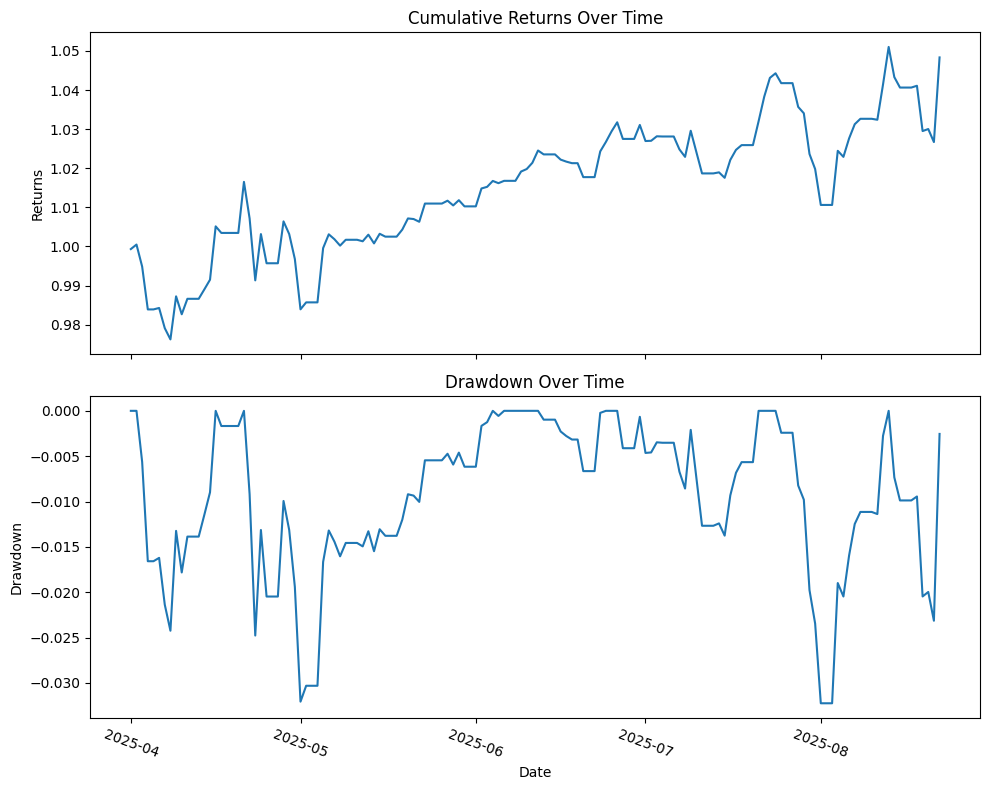

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_portfolio_value(trades_df, price_data_dict):
    """
    Compute daily portfolio value given trades and price data.
    
    trades_df: DataFrame with columns ['date', 'ticker', 'quantity', 'price', 'fees']
    price_data_dict: dict mapping ticker -> DataFrame with index 'date' and column 'close'
    
    Returns:
        portfolio_value: Series indexed by date
    """
    # Ensure date types and sort
    trades = trades_df.copy()
    trades['date'] = pd.to_datetime(trades['date'])
    trades.sort_values('date', inplace=True)

    # Determine date index range
    all_dates = pd.date_range(
        start=trades['date'].min(), 
        end=max(df.index.max() for df in price_data_dict.values()),
        freq='D'
    )
    
    # Initialize cash flow and holdings
    cash_flows = pd.Series(0.0, index=all_dates)
    holdings = {ticker: pd.Series(0.0, index=all_dates) for ticker in price_data_dict if ticker != 'CASH'}
    invested_capital = pd.Series(0.0, index=all_dates)
    
    # Process trades
    for _, row in trades.iterrows():
        dt = row['date']
        tk = row['ticker']
        qty = row['quantity']
        price = row['price']
        fees = row['fees']
        
        if tk == 'CASH':
            cash_flows.loc[dt] += qty
            invested_capital[dt:] += qty
        else:
            # Update holdings from this date onward
            holdings[tk].loc[dt:] += qty
            # Cash change: buying (positive qty) -> outflow; selling (negative qty) -> inflow
            cash_flows.loc[dt] += -qty * price - fees
    
    # Compute cumulative cash
    cash = cash_flows.cumsum()
    
    # Compute daily holdings value
    holdings_value = pd.Series(0.0, index=all_dates)
    for tk, pos in holdings.items():
        # Align prices
        # prices = price_data_dict[tk].reindex(all_dates)['close'].fillna(method='ffill')
        prices = price_data_dict[tk].reindex(all_dates)['close'].ffill()
        holdings_value += pos * prices
    
    # Total portfolio value
    portfolio_value = cash + holdings_value
    return portfolio_value, invested_capital

def compute_performance_metrics(portfolio_value, invested_capital, trading_days=252):
    """
    Compute performance metrics: CAGR, volatility, Sharpe ratio, max drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Daily returns
    daily_returns = cumulative_returns.pct_change().dropna()
    
    # CAGR
    total_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (trading_days / total_days) - 1
    
    # Volatility (annualized)
    vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (assumes risk-free rate = 0)
    sharpe = cagr / vol
    
    # Max drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()

    print(f'CAGR:                   {cagr:.2%}')
    print(f'Volatility:             {vol:.2%}')
    print(f'Sharpe Ratio:           {sharpe:.2f}')
    print(f'Max Drawdown:          -{-max_dd:.2%}')
    print(f'Total Returns:          {portfolio_value.iloc[-1] / invested_capital.iloc[-1] - 1:.2%}')
    print(f'Total PnL:             ${portfolio_value.iloc[-1] - invested_capital.iloc[-1]:.2f}')
    
    
    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

def plot_portfolio_and_drawdown(portfolio_value, invested_capital):
    """
    Plot portfolio value and drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Compute drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
    ax1.plot(cumulative_returns.index, cumulative_returns.values)
    ax1.set_title('Cumulative Returns Over Time')
    ax1.set_ylabel('Returns')
    
    ax2.plot(drawdown.index, drawdown.values)
    ax2.set_title('Drawdown Over Time')
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    plt.setp(ax2.get_xticklabels(), rotation=-20)
    
    plt.tight_layout()
    plt.show()

# Example usage:
trades_df = pd.read_excel('portfolio_tracker.xlsx')
# trades_df = trades_df.loc[trades_df['ticker'].isin(['SPY', 'TLT', 'GLD', 'SHV', 'CASH'])]
price_data_dict = {
    'SPY': pd.read_pickle(f'./data/raw/price/SPY_{CURRENT_DATE}.pkl'),
    'TLT': pd.read_pickle(f'./data/raw/price/TLT_{CURRENT_DATE}.pkl'),
    'GLD': pd.read_pickle(f'./data/raw/price/GLD_{CURRENT_DATE}.pkl'),
    'SHV': pd.read_pickle(f'./data/raw/price/SHV_{CURRENT_DATE}.pkl'),
    'PPLT': pd.read_pickle(f'./data/raw/price/PPLT_{CURRENT_DATE}.pkl'),
    'URA': pd.read_pickle(f'./data/raw/price/URA_{CURRENT_DATE}.pkl'),
    'USO': pd.read_pickle(f'./data/raw/price/USO_{CURRENT_DATE}.pkl'),
    'IBIT': pd.read_pickle(f'./data/raw/price/IBIT_{CURRENT_DATE}.pkl'),
    'EEM': pd.read_pickle(f'./data/raw/price/EEM_{CURRENT_DATE}.pkl'),
    'DBA': pd.read_pickle(f'./data/raw/price/DBA_{CURRENT_DATE}.pkl'),
    'IB01.L': pd.read_pickle(f'./data/raw/price/IB01.L_{CURRENT_DATE}.pkl'),
    'LQD': pd.read_pickle(f'./data/raw/price/LQD_{CURRENT_DATE}.pkl'),
    'CPER': pd.read_pickle(f'./data/raw/price/CPER_{CURRENT_DATE}.pkl'),
    'UUUU': pd.read_pickle(f'./data/raw/price/UUUU_{CURRENT_DATE}.pkl'),
    'ABAT': pd.read_pickle(f'./data/raw/price/ABAT_{CURRENT_DATE}.pkl'),
    'UPRO': pd.read_pickle(f'./data/raw/price/UPRO_{CURRENT_DATE}.pkl'),
    'TMF': pd.read_pickle(f'./data/raw/price/TMF_{CURRENT_DATE}.pkl'),

}
port_val, invested_cap = compute_portfolio_value(trades_df, price_data_dict)
metrics = compute_performance_metrics(port_val, invested_cap)
plot_portfolio_and_drawdown(port_val, invested_cap)
# for key in metrics:
#     print(f'{key}: {metrics[key]:.2f}')


